In [1]:
!pip install sentence-transformers transformers open_clip_torch -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.6 MB/s eta 0:00:00


In [2]:
import os, gc
import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm.auto import tqdm
from sentence_transformers import SentenceTransformer
from transformers import BlipProcessor, BlipForConditionalGeneration

PATH = "/kaggle/input/competitions/stable-diffusion-image-to-prompts"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 8
MAX_NEW_TOKENS = 75

print(f"Device: {DEVICE}")

Device: cuda


In [3]:
images = sorted(os.listdir(f"{PATH}/images"))
sample_sub = pd.read_csv(f"{PATH}/sample_submission.csv")
sample_sub['eId'] = sample_sub['imgId_eId'].str.split('_').str[1].astype(int)
EMBED_DIM = sample_sub['eId'].max() + 1  # 384
print(f"Images: {len(images)} | Embedding dim: {EMBED_DIM}")

Images: 7 | Embedding dim: 384


In [4]:
blip_processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-large"
)
blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-large",
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
    ignore_mismatched_sizes=True
).to(DEVICE).eval()

st_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
print("Models loaded ✓")

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/527 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Models loaded ✓


In [5]:
def generate_captions_batch(img_files, batch_size=BATCH_SIZE):
    captions = {}
    for i in tqdm(range(0, len(img_files), batch_size), desc="Captions"):
        batch = img_files[i : i + batch_size]
        imgs = [Image.open(f"{PATH}/images/{f}").convert("RGB") for f in batch]
        inputs = blip_processor(imgs, return_tensors="pt", padding=True).to(DEVICE)
        with torch.no_grad(), torch.amp.autocast(device_type=DEVICE, enabled=DEVICE=="cuda"):
            out = blip_model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)
        for f, ids in zip(batch, out):
            cap = blip_processor.decode(ids, skip_special_tokens=True)
            captions[f.replace(".png", "")] = cap
        gc.collect()
    return captions

captions = generate_captions_batch(images)
print(f"Sample: {list(captions.items())[0]}")

Captions:   0%|          | 0/1 [00:00<?, ?it/s]

Sample: ('20057f34d', 'arafed view of a circular hole in the middle of a desert')


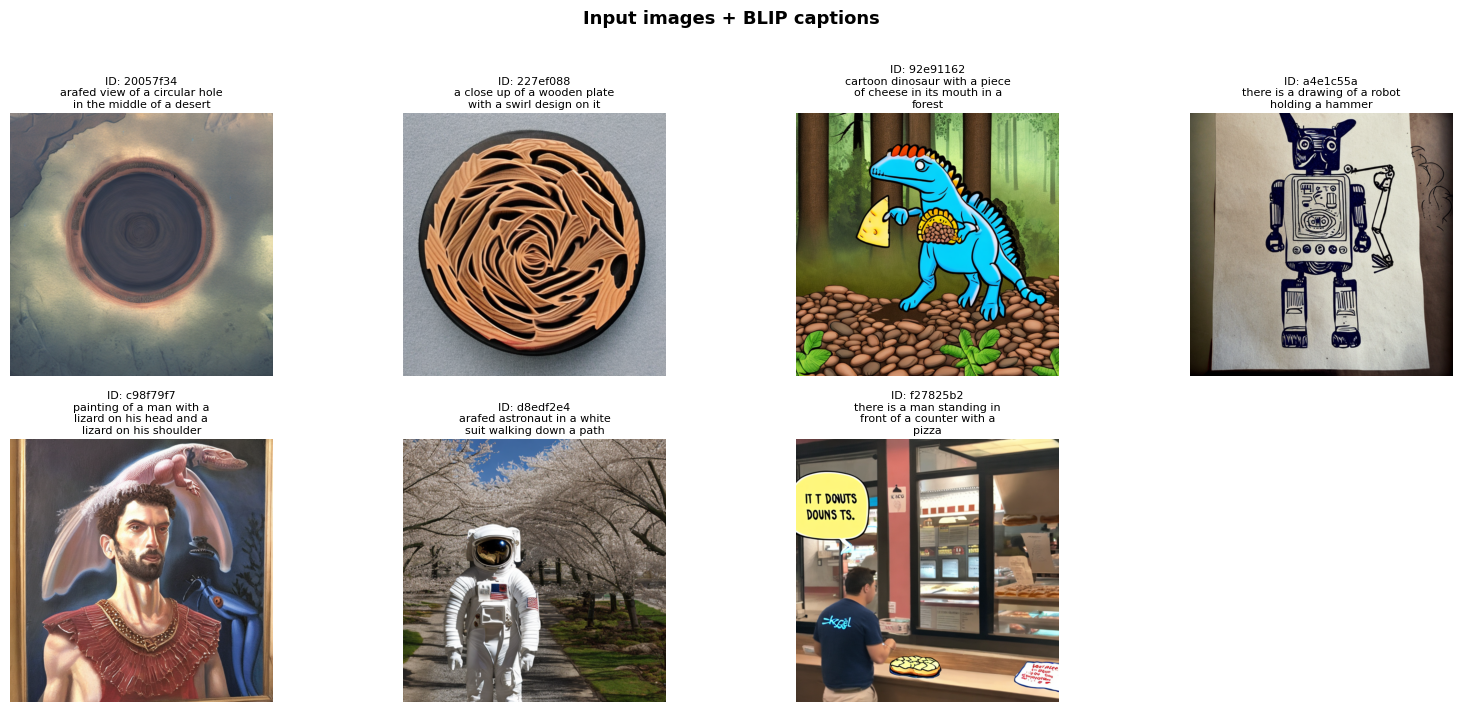

In [6]:
import matplotlib.pyplot as plt
import textwrap

n    = len(images)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
axes = axes.flatten() if n > 1 else [axes]

for idx, img_file in enumerate(images):
    img_id  = img_file.replace(".png", "")
    img     = Image.open(f"{PATH}/images/{img_file}").convert("RGB")
    caption = captions[img_id]

    axes[idx].imshow(img)
    axes[idx].set_title(
        f"ID: {img_id[:8]}\n" + "\n".join(textwrap.wrap(caption, width=30)),
        fontsize=8, pad=4
    )
    axes[idx].axis("off")

for idx in range(n, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("Input images + BLIP captions", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("input_images.png", dpi=120, bbox_inches="tight")
plt.show()

In [7]:
cap_list = [captions[f.replace(".png", "")] for f in images]

embeddings = st_model.encode(
    cap_list,
    batch_size=64,
    normalize_embeddings=True,
    show_progress_bar=True
)  # shape: (N_images, 384)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

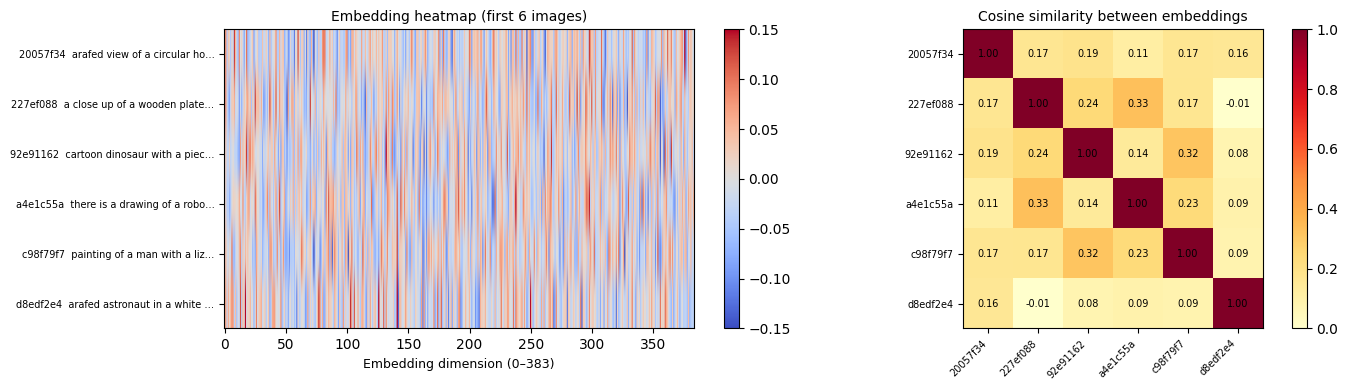

In [8]:
k          = min(6, len(images))
sample_ids = list(captions.keys())[:k]
sample_emb = embeddings[:k]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

im = axes[0].imshow(sample_emb, aspect="auto", cmap="coolwarm", vmin=-0.15, vmax=0.15)
axes[0].set_yticks(range(k))
axes[0].set_yticklabels(
    [f"{sid[:8]}  {captions[sid][:28]}…" for sid in sample_ids], fontsize=7
)
axes[0].set_xlabel("Embedding dimension (0–383)", fontsize=9)
axes[0].set_title("Embedding heatmap (first 6 images)", fontsize=10)
plt.colorbar(im, ax=axes[0])

sim   = sample_emb @ sample_emb.T
short = [sid[:8] for sid in sample_ids]
im2   = axes[1].imshow(sim, cmap="YlOrRd", vmin=0, vmax=1)
axes[1].set_xticks(range(k));  axes[1].set_xticklabels(short, rotation=45, ha="right", fontsize=7)
axes[1].set_yticks(range(k));  axes[1].set_yticklabels(short, fontsize=7)
for i in range(k):
    for j in range(k):
        axes[1].text(j, i, f"{sim[i,j]:.2f}", ha="center", va="center", fontsize=7)
axes[1].set_title("Cosine similarity between embeddings", fontsize=10)
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.savefig("embeddings_analysis.png", dpi=120, bbox_inches="tight")
plt.show()

In [9]:
img_ids = [f.replace(".png", "") for f in images]

rows = [
    {"imgId_eId": f"{img_id}_{i}", "val": float(val)}
    for img_id, emb in zip(img_ids, embeddings)
    for i, val in enumerate(emb)
]

submission_df = pd.DataFrame(rows)
submission_df.to_csv("submission.csv", index=False)
print(f"Shape: {submission_df.shape} | Expected: ({len(images) * EMBED_DIM}, 2)")
print(f"OK   : {submission_df.shape == (len(images) * EMBED_DIM, 2)}")

Shape: (2688, 2) | Expected: (2688, 2)
OK   : True


=== Submission check ===
Shape    : (2688, 2)  (expected 2688, 2)
Shape OK : True
Columns  : ['imgId_eId', 'val']
No NaNs  : True
Val range: [-0.1768, 0.1867]
Val std  : 0.0510  (near-zero = bad embeddings)

     imgId_eId       val
0  20057f34d_0  0.058347
1  20057f34d_1  0.081329
2  20057f34d_2 -0.042682
3  20057f34d_3  0.033359
4  20057f34d_4  0.017850
5  20057f34d_5 -0.045769


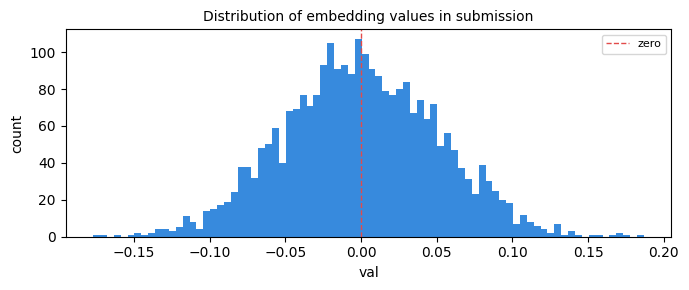

In [10]:
print("=== Submission check ===")
print(f"Shape    : {submission_df.shape}  (expected {len(images) * EMBED_DIM}, 2)")
print(f"Shape OK : {submission_df.shape == (len(images) * EMBED_DIM, 2)}")
print(f"Columns  : {list(submission_df.columns)}")
print(f"No NaNs  : {submission_df['val'].isna().sum() == 0}")
print(f"Val range: [{submission_df['val'].min():.4f}, {submission_df['val'].max():.4f}]")
print(f"Val std  : {submission_df['val'].std():.4f}  (near-zero = bad embeddings)")
print()
print(submission_df.head(6))

plt.figure(figsize=(7, 3))
plt.hist(submission_df["val"], bins=80, color="#378ADD", edgecolor="none")
plt.axvline(0, color="#E24B4A", linewidth=1, linestyle="--", label="zero")
plt.title("Distribution of embedding values in submission", fontsize=10)
plt.xlabel("val");  plt.ylabel("count")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("submission_distribution.png", dpi=120, bbox_inches="tight")
plt.show()